# Brain Tumor MRI Classification - Week 3: Transfer Learning & Experiments

**Objective:** Apply transfer learning with pretrained CNNs, compare several fine-tuning strategies, select the best model using validation results only, and evaluate it once on a held-out test split.

**Dataset:** [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset). dataset contains 7,200 labelled MRI images: 1,800 per class.  
**Duration:** Week 3 of 4-week project  
**Last updated:** May 2026

## Context & Goals

### Problem Statement
We are building a model to classify brain MRI scans into four categories:

| Class | Description |
|-------|-------------|
| **Glioma** | Malignant brain parenchyma tumor |
| **Meningioma** | Tumor of the brain membranes (dura) |
| **Pituitary** | Pituitary gland tumor |
| **No Tumor** | Healthy control scan |

The model is intended as an educational clinical decision-support prototype. It is not a medical device and should not be used for real diagnosis.

### Baseline Results (Week 2)
| Model | Test Accuracy | Test F1-Score | Notes |
|-------|---------------|---------------|-------|
| Custom CNN + augmentation | 92.31% | 92.30% | Week 2 best |
| Custom CNN without augmentation | 55.93% | 54.59% | Ablation |

### Week 3 Goals
1. Apply transfer learning with three simple strategies.
2. Use differential learning rates for full fine-tuning.
3. Select the best model using validation metrics only.
4. Evaluate the selected model on the held-out test split.
5. Add precision, recall, F1-score, confusion matrix, error analysis, and Grad-CAM.
6. Keep the notebook explainable for project defense.

---
## 1. Setup & Reproducibility

This section sets random seeds in NumPy, Python `random`, and PyTorch. It also chooses `cuda` when a GPU is available and falls back to CPU otherwise.

In [1]:
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU not available - using CPU (expect slower training)')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Active device: {DEVICE}')

GPU: Tesla T4
Active device: cuda


In [2]:
# Standard library
import os
import time
import copy
from pathlib import Path
from collections import Counter
from PIL import Image

# Data science
import pandas as pd
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(f'PyTorch : {torch.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')
print('All imports successful')

PyTorch : 2.10.0+cu128
NumPy   : 2.0.2
Pandas  : 2.2.2
All imports successful


---
## 2. Dataset Configuration

The code below auto-detects whether we are on Kaggle, Google Colab, or a local machine and resolves the dataset path. This makes the notebook portable without manual edits.

In [3]:
# Optional: auto-download on Colab
# Only runs when inside Colab AND the dataset folder does not yet exist.
IN_COLAB  = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

dataset_zip_path = Path('/content/brain-tumor-mri-dataset.zip')
dest_dir = Path('/content/data/raw')

if IN_COLAB and not IN_KAGGLE:
    if not (dest_dir / 'Training').exists():
        print('Dataset not found. Attempting to download...')

        kaggle_download_successful = False

        # First, try Kaggle API if kaggle.json is available
        kaggle_json_candidates = [
            Path('/content/kaggle.json'),
            Path('/content/drive/MyDrive/kaggle.json'),
        ]
        kaggle_json   = next((p for p in kaggle_json_candidates if p.exists()), None)

        if kaggle_json:
            print('Downloading dataset via Kaggle API...')
            !pip -q install kaggle
            !mkdir -p /content/.kaggle
            !cp -f {kaggle_json} /content/.kaggle/kaggle.json
            !chmod 600 /content/.kaggle/kaggle.json
            !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/

            # Check if Kaggle download actually produced a non-empty file
            if dataset_zip_path.exists() and dataset_zip_path.stat().st_size > 0:
                print('Kaggle download command executed and file seems present.')
                kaggle_download_successful = True
            else:
                print('Kaggle download failed or produced an empty file.')
        else:
            print('kaggle.json not found.')

        # If Kaggle download was not successful or not attempted, perform direct download
        if not kaggle_download_successful:
            print('Attempting direct download via wget (overwriting any existing file)...')
            # Always perform wget to ensure a fresh, valid download, overwriting any corrupted file.
            !wget -q --show-progress "https://www.kaggle.com/api/v1/datasets/download/masoudnickparvar/brain-tumor-mri-dataset" -O {dataset_zip_path}
            print('Direct download command executed.')

        # Now, try to unzip the dataset if the zip file exists and is valid
        if dataset_zip_path.exists() and dataset_zip_path.stat().st_size > 0:
            try:
                print(f'Unzipping {dataset_zip_path} to {dest_dir}...')
                dest_dir.mkdir(parents=True, exist_ok=True)
                !unzip -q {dataset_zip_path} -d {dest_dir}
                print('Unzip complete.')
            except Exception as e:
                print(f'Error during unzip: {e}. Please check the zip file integrity.')
                if (dest_dir / 'Training').exists(): # Check if Training folder was created despite error (e.g., partial unzip)
                    print("Partial unzip successful, 'Training' directory found.")
                else:
                    print("Unzip failed, 'Training' directory not found.")
        else:
            print('Dataset zip file not found or is empty after all download attempts.')
    else:
        print('Dataset already present at /content/data/raw/Training')
else:
    print('Kaggle/local environment — skipping download step')

Dataset not found. Attempting to download...
kaggle.json not found.
Attempting direct download via wget (overwriting any existing file)...
/content/brain-tumo 100%[===================>] 157.04M   150MB/s    in 1.0s    
Direct download command executed.
Unzipping /content/brain-tumor-mri-dataset.zip to /content/data/raw...
Unzip complete.


In [4]:
import os

# Resolve DATA_DIR across Kaggle, Colab, and local runs.
cwd = Path.cwd()
candidate_roots = [
    Path('/kaggle/input/brain-tumor-mri-dataset'),  # Kaggle
    Path('/content/data/raw'),                      # Colab
    cwd / 'data/raw',                               # local from project root
    cwd.parent / 'data/raw',                        # local from notebooks/
]

DATA_DIR = next((p for p in candidate_roots if (p / 'Training').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Dataset not found. Expected a Training/ subfolder under one of:\n  '
        + '\n  '.join(str(p) for p in candidate_roots)
    )

print(f'DATA_DIR : {DATA_DIR}')
print(f'Training : {(DATA_DIR / "Training").exists()}')
print(f'Testing  : {(DATA_DIR / "Testing").exists()}')

DATA_DIR : /content/data/raw
Training : True
Testing  : True


In [5]:
# Global hyperparameter configuration
# Centralising constants here means one change propagates everywhere.
CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_MAP   = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

IMAGE_SIZE  = 224   # standard input size for ImageNet-pretrained models
BATCH_SIZE  = 32    # increase to 64 if GPU VRAM allows
MAX_EPOCHS  = 30    # upper bound; early stopping will usually terminate earlier
PATIENCE    = 7     # stop after 7 epochs with no val_acc improvement

# Output directories
RESULTS_DIR = Path('results')
PLOTS_DIR   = RESULTS_DIR / 'plots'
MODELS_DIR  = RESULTS_DIR / 'models'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'IMAGE_SIZE={IMAGE_SIZE}  BATCH_SIZE={BATCH_SIZE}  MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}')
print(f'Classes : {CLASSES}')
print(f'Outputs : {PLOTS_DIR}/  {MODELS_DIR}/')

IMAGE_SIZE=224  BATCH_SIZE=32  MAX_EPOCHS=30  PATIENCE=7
Classes : ['glioma', 'meningioma', 'notumor', 'pituitary']
Outputs : results/plots/  results/models/


---
## 3. Data Loading, Splitting & Transforms

### Split policy
The Kaggle folders are first treated as one labelled image pool. Then the notebook creates a reproducible **stratified 70/15/15 split** with `SEED=42`:

- training split: used to update model weights
- validation split: used for model selection and early stopping
- test split: held out until the final evaluation section

This avoids test-set tuning because no test metrics are used to choose hyperparameters or select between experiments.

### Why ImageNet normalisation?
Pretrained torchvision models expect images normalised with ImageNet statistics: `mean=[0.485, 0.456, 0.406]` and `std=[0.229, 0.224, 0.225]`. Using the same normalisation keeps the input distribution close to what the pretrained filters saw originally.

In [6]:
def collect_image_paths(data_dir: Path, classes: list) -> tuple:
    """
    Traverse the dataset and return (image_paths, labels).
    Handles two layouts:
      A) <data_dir>/<class>/*.jpg         (flat)
      B) <data_dir>/{Training,Testing}/<class>/*.jpg  (Kaggle default)
    We pool both folders and apply our own stratified split.
    """
    image_paths, labels = [], []
    for class_name in classes:
        label = CLASS_MAP[class_name]
        # Layout A
        flat_dir = data_dir / class_name
        if flat_dir.exists():
            for img in flat_dir.glob('*.jpg'):
                image_paths.append(img); labels.append(label)
        # Layout B
        for subset in ['Training', 'Testing']:
            sub = data_dir / subset / class_name
            if sub.exists():
                for img in list(sub.glob('*.jpg')) + list(sub.glob('*.png')):
                    image_paths.append(img); labels.append(label)
    return image_paths, labels


image_paths, labels = collect_image_paths(DATA_DIR, CLASSES)
print(f'Total images: {len(image_paths):,}')
unique, counts = np.unique(labels, return_counts=True)
for lbl, cnt in zip(unique, counts):
    print(f'  {CLASSES[lbl]:<15}: {cnt:>5}  ({100*cnt/len(labels):.1f}%)')

Total images: 7,200
  glioma         :  1800  (25.0%)
  meningioma     :  1800  (25.0%)
  notumor        :  1800  (25.0%)
  pituitary      :  1800  (25.0%)


In [7]:
# Stratified 70 / 15 / 15 split
# stratify=labels keeps class proportions equal across train / val / test.
# SEED=42 reproduces exactly the Week 2 split.
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f'Train : {len(train_paths):>5} images  (70%)')
print(f'Val   : {len(val_paths):>5} images  (15%)')
print(f'Test  : {len(test_paths):>5} images  (15%)')

Train :  5040 images  (70%)
Val   :  1080 images  (15%)
Test  :  1080 images  (15%)


In [8]:
# ImageNet normalisation constants
# These are the exact per-channel mean and std of ImageNet.
# MANDATORY for pretrained torchvision models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform (with augmentation)
# Stronger than Week 2 to counteract larger model capacity.
# Medical justifications for each augmentation:
#   RandomCrop      -> model works at different scales/positions
#   HorizontalFlip  -> brains are anatomically symmetric
#   RandomRotation  -> patient head may be slightly tilted
#   ColorJitter     -> MRI intensity varies between scanners
#   RandomAffine    -> simulates mild head tilt / shear
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 20, IMAGE_SIZE + 20)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val / Test transform (no augmentation -- deterministic for fair evaluation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined')
print('  Train   : Resize(244) -> Crop(224) -> HFlip -> Rotate(15) -> ColorJitter -> Shear -> Normalize(ImageNet)')
print('  Val/Test: Resize(224) -> Normalize(ImageNet)')

Transforms defined
  Train   : Resize(244) -> Crop(224) -> HFlip -> Rotate(15) -> ColorJitter -> Shear -> Normalize(ImageNet)
  Val/Test: Resize(224) -> Normalize(ImageNet)


In [9]:
# Custom PyTorch Dataset
# PyTorch needs a Dataset that loads one sample at a time.
# The DataLoader calls __getitem__ in parallel to fill batches.
class BrainMRIDataset(Dataset):
    """
    Brain Tumor MRI Dataset wrapper.

    Args:
        image_paths : list[Path] -- file paths to JPEG/PNG images
        labels      : list[int]  -- integer class indices (0-3)
        transform   : torchvision Compose pipeline
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # .convert('RGB') turns grayscale MRI (1 channel) into 3-channel
        # required because pretrained models expect 3-channel input
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# NUM_WORKERS=0 on CPU (no overhead); 2 on GPU (async prefetch)
# PIN_MEMORY=True speeds up CPU->GPU transfers (only meaningful on CUDA)
NUM_WORKERS = 0 if DEVICE.type == 'cpu' else 2
PIN_MEMORY  = DEVICE.type == 'cuda'

def make_loaders(train_aug: bool = True):
    """Build and return (train_loader, val_loader, test_loader)."""
    t_tfm    = train_transform if train_aug else val_test_transform
    train_ds = BrainMRIDataset(train_paths, train_labels, transform=t_tfm)
    val_ds   = BrainMRIDataset(val_paths,   val_labels,   transform=val_test_transform)
    test_ds  = BrainMRIDataset(test_paths,  test_labels,  transform=val_test_transform)

    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return (
        DataLoader(train_ds, shuffle=True,  **kw),
        DataLoader(val_ds,   shuffle=False, **kw),
        DataLoader(test_ds,  shuffle=False, **kw),
    )


train_loader, val_loader, test_loader = make_loaders(train_aug=True)

# Sanity check
sample_imgs, sample_lbls = next(iter(train_loader))
print(f'Batch shape : {sample_imgs.shape}  -> (B, C, H, W)')
print(f'Label sample: {sample_lbls[:8].tolist()}')
print(f'Pixel range : [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]  (ImageNet-normalised)')

Batch shape : torch.Size([32, 3, 224, 224])  -> (B, C, H, W)
Label sample: [0, 3, 0, 3, 1, 2, 1, 2]
Pixel range : [-2.12, 2.64]  (ImageNet-normalised)


---
## 4. Training Infrastructure

We write **four reusable functions** so every experiment uses identical evaluation logic:
- `train_epoch` — forward + backward over training batches
- `validate` — forward only over val batches (`torch.no_grad()`)
- `evaluate_model` — collect all predictions and compute all metrics
- `train_model` — orchestrates epochs, early stopping, and checkpointing

Writing this once and calling it for every experiment prevents inconsistencies.

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    """
    One full forward + backward pass over the training set.

    model.train() activates:
      - Dropout  (randomly zeros neurons -> regularisation)
      - BatchNorm in training mode (uses current-batch statistics)

    Returns: (avg_loss_per_sample, accuracy_%)
    """
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, lbls in tqdm(loader, leave=False, desc='  Train'):
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()            # clear previous gradients
        outputs = model(imgs)            # forward: (B, NUM_CLASSES) logits
        loss    = criterion(outputs, lbls)  # CrossEntropy = log-softmax + NLL
        loss.backward()                  # backprop: compute gradients
        optimizer.step()                 # gradient descent step

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == lbls).sum().item()
        n          += imgs.size(0)

    return total_loss / n, 100.0 * correct / n


@torch.no_grad()  # disables gradient computation -> faster, less memory
def validate(model, loader, criterion, device):
    """
    Evaluate on the validation set -- no weight updates.

    model.eval() activates:
      - Dropout disabled (all neurons active for stable inference)
      - BatchNorm uses running statistics, not batch statistics

    Returns: (avg_loss_per_sample, accuracy_%)
    """
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, lbls)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == lbls).sum().item()
        n          += imgs.size(0)

    return total_loss / n, 100.0 * correct / n


@torch.no_grad()
def evaluate_model(model, loader, device):
    """
    Full evaluation: collect all predictions and return metrics dict.

    WARNING: Only call on the TEST set for final reporting.
    Using test metrics to select the model = data leakage.
    """
    model.eval()
    all_preds, all_labels = [], []

    for imgs, lbls in tqdm(loader, desc='  Evaluating', leave=False):
        preds = model(imgs.to(device)).argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lbls.tolist())

    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)

    return {
        'accuracy'        : accuracy_score(labels_arr, preds_arr),
        'precision'       : precision_score(labels_arr, preds_arr, average='weighted', zero_division=0),
        'recall'          : recall_score(labels_arr, preds_arr, average='weighted', zero_division=0),
        'f1'              : f1_score(labels_arr, preds_arr, average='weighted', zero_division=0),
        'confusion_matrix': confusion_matrix(labels_arr, preds_arr),
        'predictions'     : preds_arr,
        'labels'          : labels_arr,
    }


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, max_epochs, patience, device, model_name='model'):
    """
    Full training loop with two callbacks:
      ModelCheckpoint : saves best weights (highest val_acc)
      EarlyStopping   : stops after `patience` epochs with no improvement

    Always restores the best checkpoint before returning.
    Returns: history dict {train_loss, train_acc, val_loss, val_acc}
    """
    history        = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc   = 0.0
    best_weights   = copy.deepcopy(model.state_dict())
    patience_count = 0
    save_path      = MODELS_DIR / f'{model_name}.pth'

    print(f'\n{"="*72}')
    print(f'  Training: {model_name}   max_epochs={max_epochs}  patience={patience}')
    print(f'{"="*72}')
    t0 = time.time()

    for epoch in range(max_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = validate(model, val_loader, criterion, device)

        # LR scheduler step
        # ReduceLROnPlateau needs the monitored metric; other schedulers don't
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va_loss)
        else:
            scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        lr_now  = optimizer.param_groups[0]['lr']
        marker  = 'NEW BEST' if va_acc > best_val_acc else ''
        print(f'  Epoch {epoch+1:3d}/{max_epochs}  '
              f'Train {tr_loss:.4f}/{tr_acc:5.2f}%  '
              f'Val {va_loss:.4f}/{va_acc:5.2f}%  '
              f'LR={lr_now:.1e}  {marker}')

        # ModelCheckpoint
        if va_acc > best_val_acc:
            best_val_acc   = va_acc
            best_weights   = copy.deepcopy(model.state_dict())
            patience_count = 0
            torch.save({
                'epoch'           : epoch + 1,
                'model_state_dict': best_weights,
                'val_acc'         : va_acc,
            }, save_path)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'\n  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
                break

    elapsed = time.time() - t0
    print(f'\n  Done in {elapsed/60:.1f} min  |  Best val acc = {best_val_acc:.2f}%')
    print(f'  Best weights saved -> {save_path}')
    model.load_state_dict(best_weights)  # always restore best checkpoint
    return history


print('Training infrastructure ready: train_epoch / validate / evaluate_model / train_model')

Training infrastructure ready: train_epoch / validate / evaluate_model / train_model


---
## 5. Why Transfer Learning?

**Transfer learning** reuses a network already trained on a large dataset (ImageNet: 1.2M images, 1000 classes) as a starting point for our smaller task.

### Why it works for MRI
CNNs learn a **feature hierarchy**: early layers detect edges and textures (universal); later layers detect task-specific patterns. MRI scans contain the same kinds of edges, blobs, and regions of contrast — so ImageNet features transfer even across domains.

### Strategies we test

| Strategy | Backbone | Classifier Head | When to use |
|----------|----------|-----------------|-------------|
| Feature Extraction | Frozen | Trainable | Fast; very small data |
| Full Fine-tuning | Low LR | Higher LR | Best accuracy; medium data |

**Catastrophic forgetting:** If backbone LR is too high, pretrained weights are overwritten in the first few steps. We prevent this with *differential learning rates*.

---
## 6. Experiment 1 - ResNet18: Feature Extraction (Frozen Backbone)

**Architecture:** ResNet18 has skip connections that make deeper CNNs easier to train.

**Strategy:** Freeze all pretrained backbone weights and train only a new 4-class classifier head. This is fast and useful as a transfer-learning baseline.

**Expectation:** It should train quickly, but it may underperform because the frozen ImageNet backbone cannot adapt to MRI-specific texture patterns.

In [11]:
def build_resnet18_frozen(num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    ResNet18 with frozen backbone -- only the new FC head is trained.

    Head: Dropout(0.4) -> Linear(512->256) -> ReLU -> Dropout(0.3) -> Linear(256->4)
    Two dropout layers prevent the head overfitting with such few trainable params.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze ALL backbone parameters
    # requires_grad=False means PyTorch skips gradient calculation for these params
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final FC (512 -> 1000) with our 4-class head
    in_features = model.fc.in_features  # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),  # raw logits; CrossEntropyLoss applies softmax internally
    )
    return model


model_exp1 = build_resnet18_frozen().to(DEVICE)

total_p   = sum(p.numel() for p in model_exp1.parameters())
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f'ResNet18 -- Feature Extraction (frozen backbone)')
print(f'  Total params     : {total_p:>10,}')
print(f'  Trainable params : {trainable:>10,}  ({100*trainable/total_p:.1f}%)')
print(f'  Frozen params    : {total_p-trainable:>10,}  ({100*(total_p-trainable)/total_p:.1f}%)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


ResNet18 -- Feature Extraction (frozen backbone)
  Total params     : 11,308,868
  Trainable params :    132,356  (1.2%)
  Frozen params    : 11,176,512  (98.8%)


In [12]:
# Loss, Optimizer, Scheduler for Experiment 1
# CrossEntropyLoss: standard for multi-class; combines log-softmax + NLL in one stable step.
criterion_exp1 = nn.CrossEntropyLoss()

# filter() passes only the head parameters (requires_grad=True) to Adam
optimizer_exp1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=1e-3, weight_decay=1e-4
)

# ReduceLROnPlateau: halves LR if val_loss doesn't improve for 3 epochs.
# Note: the `verbose` parameter was deprecated in PyTorch >= 2.2; removed here.
scheduler_exp1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp1, mode='min', factor=0.5, patience=3
)

print('Experiment 1 -- ResNet18 Feature Extraction')
print('  Trainable : FC head only')
print('  Optimizer : Adam  lr=1e-3  weight_decay=1e-4')
print('  Scheduler : ReduceLROnPlateau  factor=0.5  patience=3')
print('  Loss      : CrossEntropyLoss')

Experiment 1 -- ResNet18 Feature Extraction
  Trainable : FC head only
  Optimizer : Adam  lr=1e-3  weight_decay=1e-4
  Scheduler : ReduceLROnPlateau  factor=0.5  patience=3
  Loss      : CrossEntropyLoss


In [13]:
history_exp1 = train_model(
    model        = model_exp1,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion_exp1,
    optimizer    = optimizer_exp1,
    scheduler    = scheduler_exp1,
    max_epochs   = MAX_EPOCHS,
    patience     = PATIENCE,
    device       = DEVICE,
    model_name   = 'resnet18_frozen',
)


  Training: resnet18_frozen   max_epochs=30  patience=7


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   1/30  Train 0.8010/67.58%  Val 0.7776/62.13%  LR=1.0e-03  NEW BEST


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   2/30  Train 0.6348/74.96%  Val 0.5145/81.48%  LR=1.0e-03  NEW BEST


...

  Epoch   7/30  Train 0.5611/77.78%  Val 0.5314/77.96%  LR=1.0e-03  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   8/30  Train 0.5508/78.45%  Val 0.5003/79.26%  LR=1.0e-03  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   9/30  Train 0.5331/78.83%  Val 0.5906/74.07%  LR=1.0e-03  

  Early stopping at epoch 9 (no improvement for 7 epochs)

  Done in 5.6 min  |  Best val acc = 81.48%
  Best weights saved -> results/models/resnet18_frozen.pth


---
## 7. Experiment 2 — ResNet18: Full Fine-Tuning

**Strategy:** Unfreeze ALL layers. Use **differential learning rates**:
- Backbone: `lr = 1e-4` (10× slower — preserves ImageNet features)
- Head: `lr = 1e-3` (fast convergence of the new classifier)

**Why different LRs?** A large LR on the backbone destroys pretrained weights in the first few steps (*catastrophic forgetting*). Keeping it small allows gentle adaptation to MRI patterns.

**Hypothesis:** All layers adapting to MRI textures → better accuracy than frozen Exp 1.

In [14]:
def build_resnet18_finetune(num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    ResNet18 with ALL layers trainable.
    Same head as Exp 1; the difference is in the optimizer (differential LRs).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    # All params have requires_grad=True by default -- nothing to unfreeze
    return model


model_exp2 = build_resnet18_finetune().to(DEVICE)
total_p    = sum(p.numel() for p in model_exp2.parameters())
print(f'ResNet18 -- Full Fine-Tuning')
print(f'  Total/Trainable params: {total_p:,} / {total_p:,}  (100% trainable)')

ResNet18 -- Full Fine-Tuning
  Total/Trainable params: 11,308,868 / 11,308,868  (100% trainable)


In [15]:
# Differential learning rates
# Group 1 (backbone): all params except the new fc head  -> lr = 1e-4 (small)
# Group 2 (head):     new fc parameters                  -> lr = 1e-3 (standard)
backbone_params = [p for name, p in model_exp2.named_parameters() if 'fc' not in name]
head_params     = list(model_exp2.fc.parameters())

criterion_exp2 = nn.CrossEntropyLoss()
optimizer_exp2 = optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},  # slow backbone
    {'params': head_params,     'lr': 1e-3},  # fast head
], weight_decay=1e-4)

scheduler_exp2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp2, mode='min', factor=0.5, patience=3
)

print('Experiment 2 -- ResNet18 Full Fine-Tuning')
print('  Backbone LR : 1e-4  (avoids catastrophic forgetting)')
print('  Head LR     : 1e-3  (fast new classifier learning)')
print('  Optimizer   : Adam  weight_decay=1e-4')
print('  Scheduler   : ReduceLROnPlateau  factor=0.5  patience=3')

Experiment 2 -- ResNet18 Full Fine-Tuning
  Backbone LR : 1e-4  (avoids catastrophic forgetting)
  Head LR     : 1e-3  (fast new classifier learning)
  Optimizer   : Adam  weight_decay=1e-4
  Scheduler   : ReduceLROnPlateau  factor=0.5  patience=3


In [16]:
history_exp2 = train_model(
    model        = model_exp2,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion_exp2,
    optimizer    = optimizer_exp2,
    scheduler    = scheduler_exp2,
    max_epochs   = MAX_EPOCHS,
    patience     = PATIENCE,
    device       = DEVICE,
    model_name   = 'resnet18_finetune',
)


  Training: resnet18_finetune   max_epochs=30  patience=7


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   1/30  Train 0.3920/85.36%  Val 0.2179/92.41%  LR=1.0e-04  NEW BEST


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   2/30  Train 0.1669/94.38%  Val 0.1723/94.54%  LR=1.0e-04  NEW BEST


...

  Epoch  28/30  Train 0.0039/99.86%  Val 0.1329/98.24%  LR=6.3e-06  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch  29/30  Train 0.0045/99.82%  Val 0.1331/98.24%  LR=6.3e-06  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch  30/30  Train 0.0043/99.80%  Val 0.1405/98.24%  LR=3.1e-06  

  Done in 20.4 min  |  Best val acc = 98.24%
  Best weights saved -> results/models/resnet18_finetune.pth


---
## 8. Experiment 3 - EfficientNet-B0: Full Fine-Tuning

**Architecture:** EfficientNet-B0 uses compound scaling and depthwise separable convolutions, giving strong accuracy with relatively few parameters.

**Why include it?** It is a compact alternative to ResNet18 and is often competitive in transfer-learning tasks.

**Changes vs Exp 2:** Different architecture family, AdamW optimizer, and CosineAnnealingLR scheduler.

In [17]:
def build_efficientnet_b0(num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    EfficientNet-B0 with pretrained ImageNet weights.

    Original classifier: Sequential(Dropout, Linear(1280 -> 1000))
    We replace it with a 4-class head. in_features = 1280 for B0.
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )
    return model


model_exp3 = build_efficientnet_b0().to(DEVICE)
total_p    = sum(p.numel() for p in model_exp3.parameters())
print(f'EfficientNet-B0 -- Full Fine-Tuning')
print(f'  Total/Trainable params: {total_p:,} / {total_p:,}  (100% trainable)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]

EfficientNet-B0 -- Full Fine-Tuning
  Total/Trainable params: 4,336,512 / 4,336,512  (100% trainable)


In [18]:
# Differential LR for EfficientNet
# Very conservative backbone LR (5e-5) because EfficientNet's compound-scaled
# weights are more sensitive to large gradient updates than ResNet.
backbone_params_e = [p for name, p in model_exp3.named_parameters() if 'classifier' not in name]
head_params_e     = list(model_exp3.classifier.parameters())

criterion_exp3 = nn.CrossEntropyLoss()

# AdamW: applies weight decay directly on parameters (not via gradient),
# which is theoretically correct and slightly better regularisation than Adam.
optimizer_exp3 = optim.AdamW([
    {'params': backbone_params_e, 'lr': 5e-5},  # very conservative
    {'params': head_params_e,     'lr': 1e-3},
], weight_decay=1e-3)

# CosineAnnealingLR: smoothly decays LR following a cosine curve from
# initial value to eta_min. Smoother than step-based schedulers for fine-tuning.
scheduler_exp3 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_exp3, T_max=MAX_EPOCHS, eta_min=1e-6
)

print('Experiment 3 -- EfficientNet-B0 Full Fine-Tuning')
print('  Backbone LR : 5e-5   (very conservative for EfficientNet)')
print('  Head LR     : 1e-3')
print('  Optimizer   : AdamW  weight_decay=1e-3')
print('  Scheduler   : CosineAnnealingLR  T_max=30  eta_min=1e-6')

Experiment 3 -- EfficientNet-B0 Full Fine-Tuning
  Backbone LR : 5e-5   (very conservative for EfficientNet)
  Head LR     : 1e-3
  Optimizer   : AdamW  weight_decay=1e-3
  Scheduler   : CosineAnnealingLR  T_max=30  eta_min=1e-6


In [19]:
history_exp3 = train_model(
    model        = model_exp3,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion_exp3,
    optimizer    = optimizer_exp3,
    scheduler    = scheduler_exp3,
    max_epochs   = MAX_EPOCHS,
    patience     = PATIENCE,
    device       = DEVICE,
    model_name   = 'efficientnet_b0',
)


  Training: efficientnet_b0   max_epochs=30  patience=7


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   1/30  Train 0.4759/82.66%  Val 0.3300/88.15%  LR=5.0e-05  NEW BEST


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch   2/30  Train 0.2544/90.89%  Val 0.2051/91.85%  LR=4.9e-05  NEW BEST


...

  Epoch  28/30  Train 0.0124/99.54%  Val 0.1134/97.31%  LR=1.5e-06  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch  29/30  Train 0.0193/99.35%  Val 0.1108/97.69%  LR=1.1e-06  


  Train:   0%|          | 0/158 [00:00<?, ?it/s]

  Epoch  30/30  Train 0.0128/99.52%  Val 0.1072/97.78%  LR=1.0e-06  

  Done in 21.7 min  |  Best val acc = 97.78%
  Best weights saved -> results/models/efficientnet_b0.pth


---
## 9. Training Curves — All Experiments

Plotting all three experiments together lets us compare:
- **Convergence speed** — which model learns fastest per epoch?
- **Final accuracy** — which reaches the highest val accuracy?
- **Overfitting** — how large is the train–val gap?

Solid lines = validation (what matters); faded lines = training.

Saved -> results/plots/week3_training_curves.png


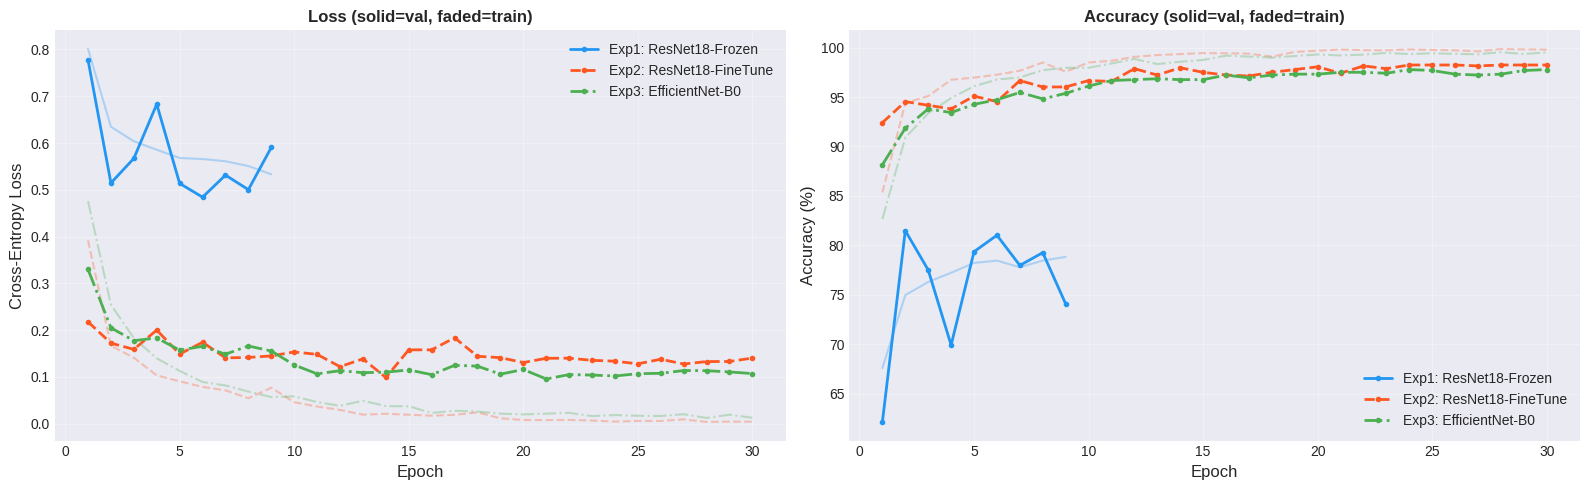

In [20]:
def plot_training_curves(histories: dict, save_path=None):
    """Plot loss & accuracy curves. histories = {label: history_dict}"""
    COLORS = ['#2196F3', '#FF5722', '#4CAF50']
    STYLES = ['-', '--', '-.']

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 5))

    for idx, (label, hist) in enumerate(histories.items()):
        c  = COLORS[idx % len(COLORS)]
        ls = STYLES[idx % len(STYLES)]
        ep = range(1, len(hist['train_loss']) + 1)

        ax_loss.plot(ep, hist['train_loss'], linestyle=ls, color=c, alpha=0.3)
        ax_loss.plot(ep, hist['val_loss'],   linestyle=ls, color=c, lw=2.0,
                     marker='o', markersize=3, label=label)
        ax_acc.plot( ep, hist['train_acc'],  linestyle=ls, color=c, alpha=0.3)
        ax_acc.plot( ep, hist['val_acc'],    linestyle=ls, color=c, lw=2.0,
                     marker='o', markersize=3, label=label)

    for ax, ylabel, title in zip(
        [ax_loss, ax_acc],
        ['Cross-Entropy Loss', 'Accuracy (%)'],
        ['Loss (solid=val, faded=train)', 'Accuracy (solid=val, faded=train)'],
    ):
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()


all_histories = {
    'Exp1: ResNet18-Frozen'   : history_exp1,
    'Exp2: ResNet18-FineTune' : history_exp2,
    'Exp3: EfficientNet-B0'   : history_exp3,
}

plot_training_curves(all_histories, save_path=PLOTS_DIR / 'week3_training_curves.png')

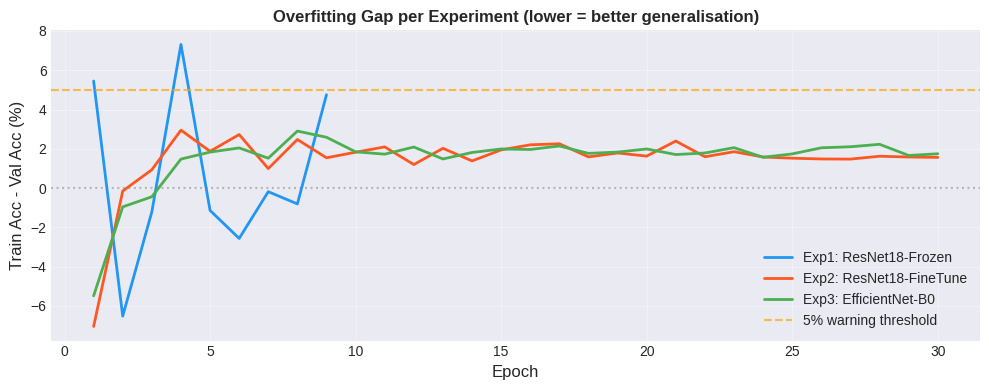

Overfitting gap plot saved

Final Train-Val Accuracy Gaps:
  Exp1: ResNet18-Frozen             : +4.76%  [good]
  Exp2: ResNet18-FineTune           : +1.56%  [good]
  Exp3: EfficientNet-B0             : +1.75%  [good]


In [21]:
# Overfitting gap analysis
# Gap = train_acc - val_acc per epoch.
# A large gap means the model memorises training data but fails to generalise.
# A gap < 5% is generally acceptable; > 10% indicates a problem.

fig, ax = plt.subplots(figsize=(10, 4))
COLORS = ['#2196F3', '#FF5722', '#4CAF50']

for (label, hist), c in zip(all_histories.items(), COLORS):
    gap = np.array(hist['train_acc']) - np.array(hist['val_acc'])
    ax.plot(range(1, len(gap) + 1), gap, color=c, linewidth=2, label=label)

ax.axhline(y=5,  color='orange', linestyle='--', alpha=0.7, label='5% warning threshold')
ax.axhline(y=0,  color='gray',   linestyle=':',  alpha=0.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Train Acc - Val Acc (%)', fontsize=12)
ax.set_title('Overfitting Gap per Experiment (lower = better generalisation)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_overfitting_gap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Overfitting gap plot saved')

print('\nFinal Train-Val Accuracy Gaps:')
for label, hist in all_histories.items():
    gap    = hist['train_acc'][-1] - hist['val_acc'][-1]
    status = 'good' if gap < 5 else ('moderate' if gap < 10 else 'HIGH -- consider regularisation')
    print(f'  {label:<34}: {gap:+.2f}%  [{status}]')

---
## 10. Model Comparison - Validation Set

> **Key principle:** the **validation set** is used for model selection.  
> The **test set** stays locked until Section 11.
>
> The Week 2 CNN result is included only as a historical reference. The Week 3 winner is chosen only from Week 3 validation metrics.

In [22]:
# Evaluate all experiments on the validation set (for model selection only)
print('Evaluating on validation set...')
val_results = {
    'exp1': evaluate_model(model_exp1, val_loader, DEVICE),
    'exp2': evaluate_model(model_exp2, val_loader, DEVICE),
    'exp3': evaluate_model(model_exp3, val_loader, DEVICE),
}

exp_labels = {
    'exp1': 'Exp1: ResNet18 Frozen',
    'exp2': 'Exp2: ResNet18 FineTune',
    'exp3': 'Exp3: EfficientNet-B0',
}

# Build leaderboard including the Week 2 baseline for reference
rows = [{'Model': 'Week 2 Custom CNN (baseline)',
         'Acc': 92.31, 'Prec': 92.30, 'Rec': 92.31, 'F1': 92.30, 'Set': 'Test'}]

for key in ['exp1', 'exp2', 'exp3']:
    r = val_results[key]
    rows.append({
        'Model': exp_labels[key],
        'Acc'  : round(r['accuracy']  * 100, 2),
        'Prec' : round(r['precision'] * 100, 2),
        'Rec'  : round(r['recall']    * 100, 2),
        'F1'   : round(r['f1']        * 100, 2),
        'Set'  : 'Val',
    })

leaderboard = pd.DataFrame(rows)
leaderboard.columns = ['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'Eval Set']

print('\n' + '='*80)
print(' EXPERIMENT LEADERBOARD')
print('='*80)
print(leaderboard.to_string(index=False))
print('='*80)

best_key   = max(['exp1', 'exp2', 'exp3'], key=lambda k: val_results[k]['accuracy'])
best_model = {'exp1': model_exp1, 'exp2': model_exp2, 'exp3': model_exp3}[best_key]
print(f'\nBest model: {exp_labels[best_key]}  (val acc = {val_results[best_key]["accuracy"]*100:.2f}%)')

Evaluating on validation set...


  Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]


 EXPERIMENT LEADERBOARD
                       Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%) Eval Set
Week 2 Custom CNN (baseline)         92.31          92.30       92.31         92.30     Test
       Exp1: ResNet18 Frozen         81.48          81.39       81.48         81.01      Val
     Exp2: ResNet18 FineTune         98.24          98.25       98.24         98.24      Val
       Exp3: EfficientNet-B0         97.78          97.81       97.78         97.78      Val

Best model: Exp2: ResNet18 FineTune  (val acc = 98.24%)


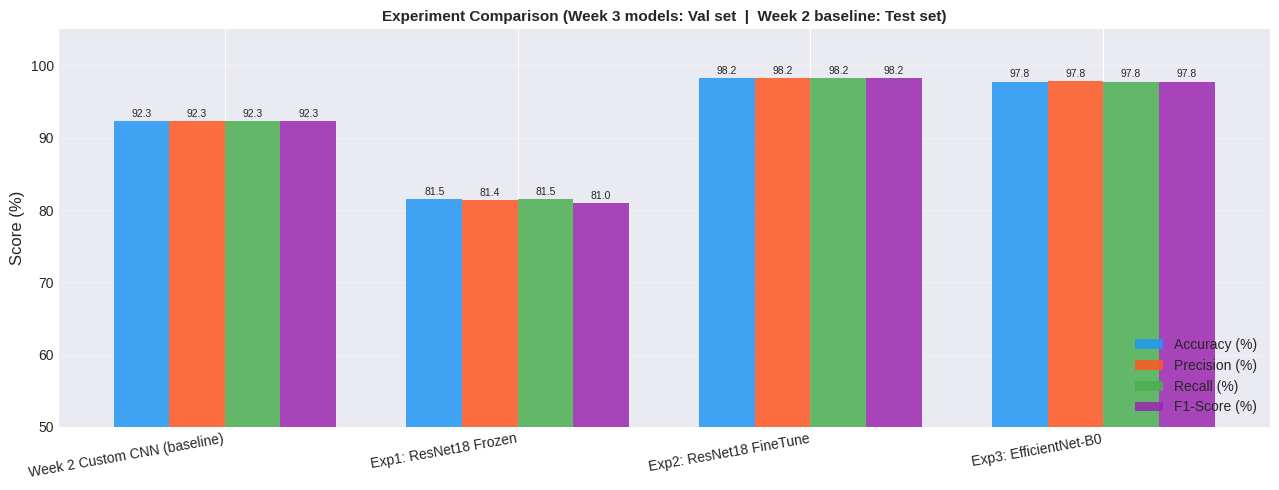

Comparison chart saved


In [23]:
# Grouped bar chart: all metrics side by side
fig, ax = plt.subplots(figsize=(13, 5))

metric_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
bar_colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
x     = np.arange(len(leaderboard))
width = 0.19

for i, (col, clr) in enumerate(zip(metric_cols, bar_colors)):
    bars = ax.bar(x + i * width, leaderboard[col], width, label=col, color=clr, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(leaderboard['Model'], rotation=10, ha='right', fontsize=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim([50, 105])
ax.set_title('Experiment Comparison (Week 3 models: Val set  |  Week 2 baseline: Test set)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Comparison chart saved')

---
## 11. Final Evaluation - Best Model on Test Set

The selected model is evaluated on the held-out test split after model selection is finished. Test metrics are used for final reporting, not for choosing between experiments.

In [24]:
print(f'Evaluating {exp_labels[best_key]} on HELD-OUT TEST SET (one-time evaluation)...')
test_results = evaluate_model(best_model, test_loader, DEVICE)

print('\n' + '='*60)
print(f' FINAL TEST RESULTS -- {exp_labels[best_key]}')
print('='*60)
print(f'  Accuracy  : {test_results["accuracy"]  * 100:.2f}%')
print(f'  Precision : {test_results["precision"] * 100:.2f}%')
print(f'  Recall    : {test_results["recall"]    * 100:.2f}%')
print(f'  F1-Score  : {test_results["f1"]        * 100:.2f}%')
print('='*60)
print(f'  vs Week 2 CNN : {(test_results["accuracy"] - 0.9231)*100:+.2f} percentage points')

Evaluating Exp2: ResNet18 FineTune on HELD-OUT TEST SET (one-time evaluation)...


  Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]


 FINAL TEST RESULTS -- Exp2: ResNet18 FineTune
  Accuracy  : 99.07%
  Precision : 99.07%
  Recall    : 99.07%
  F1-Score  : 99.07%
  vs Week 2 CNN : +6.76 percentage points


In [25]:
# Per-class classification report
print('Per-Class Classification Report:')
print(classification_report(
    test_results['labels'],
    test_results['predictions'],
    target_names=CLASSES, digits=4
))

Per-Class Classification Report:
              precision    recall  f1-score   support

      glioma     0.9852    0.9852    0.9852       270
  meningioma     0.9888    0.9852    0.9870       270
     notumor     0.9926    0.9963    0.9945       270
   pituitary     0.9963    0.9963    0.9963       270

    accuracy                         0.9907      1080
   macro avg     0.9907    0.9907    0.9907      1080
weighted avg     0.9907    0.9907    0.9907      1080



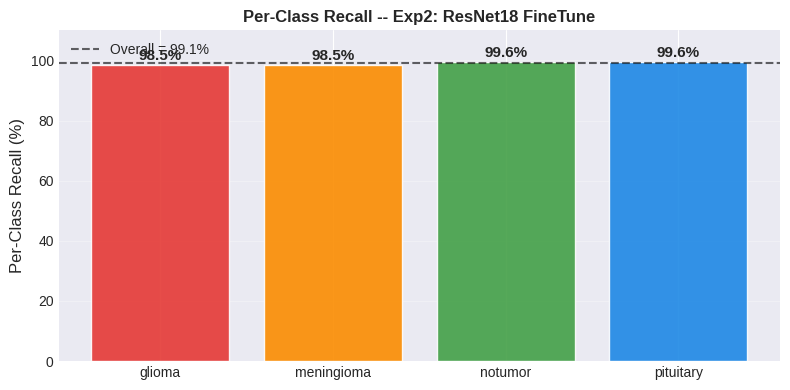

Per-class recall chart saved


In [26]:
# Per-class recall bar chart
# In a medical project, per-class recall matters because a model can have high
# overall accuracy while still missing one important tumor type.
cm_raw = test_results['confusion_matrix']
per_cls_recall = cm_raw.diagonal() / cm_raw.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
bar_clrs = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
bars = ax.bar(CLASSES, per_cls_recall * 100, color=bar_clrs, alpha=0.9, edgecolor='white')

for bar, recall in zip(bars, per_cls_recall):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{recall*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=test_results['accuracy'] * 100, color='black', linestyle='--',
           alpha=0.6, label=f'Overall = {test_results["accuracy"]*100:.1f}%')
ax.set_ylabel('Per-Class Recall (%)', fontsize=12)
ax.set_title(f'Per-Class Recall -- {exp_labels[best_key]}', fontsize=12, fontweight='bold')
ax.set_ylim([0, 110])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_per_class_recall.png', dpi=120, bbox_inches='tight')
plt.show()
print('Per-class recall chart saved')

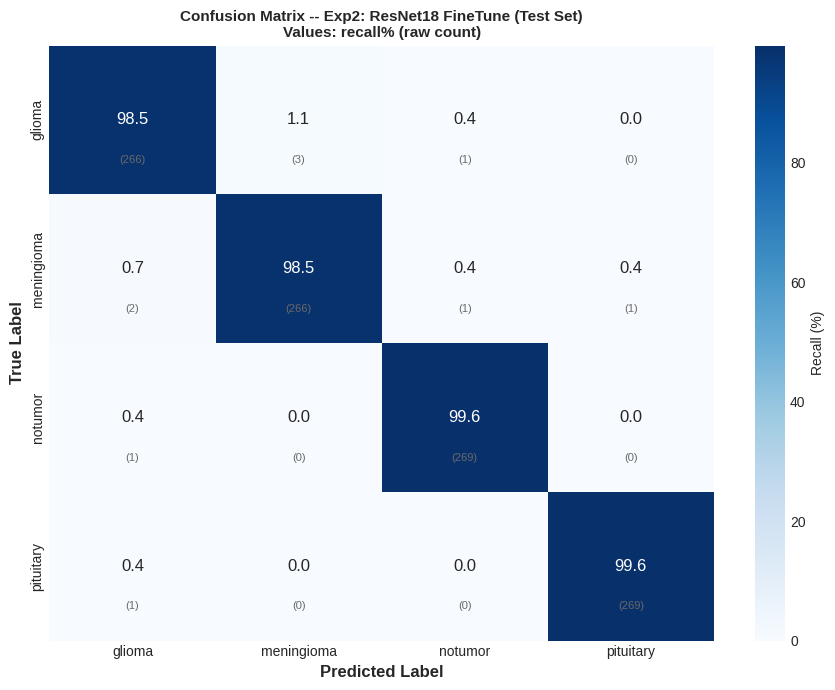

Confusion matrix saved


In [27]:
# Confusion matrix
# Each cell: percentage recall (row normalised) + raw count in parentheses
# Diagonal = correct; off-diagonal = errors
fig, ax = plt.subplots(figsize=(9, 7))

cm_pct = cm_raw.astype('float') / cm_raw.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    cbar_kws={'label': 'Recall (%)'},
    annot_kws={'size': 12},
)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j + 0.5, i + 0.77, f'({cm_raw[i, j]})',
                ha='center', va='center', fontsize=8, color='dimgray')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=12, fontweight='bold')
ax.set_title(
    f'Confusion Matrix -- {exp_labels[best_key]} (Test Set)\nValues: recall% (raw count)',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Confusion matrix saved')

---
## 12. Error Analysis

Understanding where the model fails is as important as overall accuracy, especially for medical imaging. This section collects every misclassified test image, displays a small sample, and counts the most common true-to-predicted error pairs.

In [28]:
@torch.no_grad()
def collect_misclassified(model, loader, device, max_samples=None):
    """
    Return misclassified examples:
      (img_tensor, true_label, pred_label, confidence_in_wrong_pred)
    Confidence = softmax probability assigned to the incorrect predicted class.
    """
    model.eval()
    missed = []
    for imgs, lbls in loader:
        logits = model(imgs.to(device))
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(1)
        for i in range(len(lbls)):
            if preds[i].item() != lbls[i].item():
                conf = probs[i, preds[i]].item()
                missed.append((imgs[i].cpu(), lbls[i].item(), preds[i].item(), conf))
        if max_samples is not None and len(missed) >= max_samples:
            return missed[:max_samples]
    return missed


all_misclassified = collect_misclassified(best_model, test_loader, DEVICE)
misclassified = all_misclassified[:10]
print(f'Found {len(all_misclassified)} total misclassified samples; displaying {len(misclassified)}')

Found 10 total misclassified samples; displaying 10


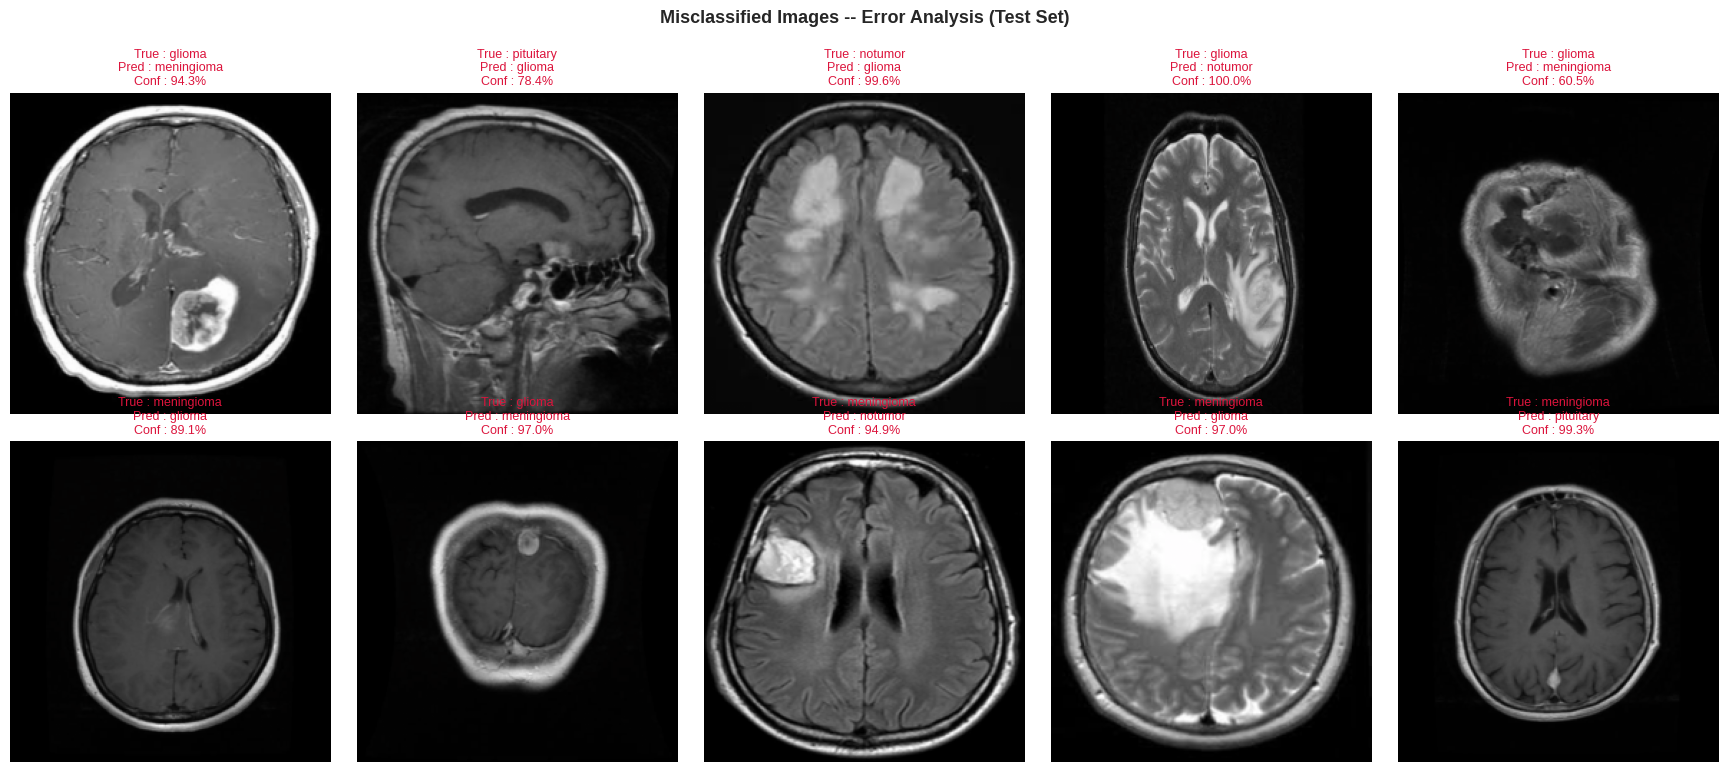

Misclassified images saved


In [29]:
# Denormalisation helper
# Images were normalised with ImageNet stats before training.
# To display them: x_display = (x_normalised * std) + mean
def denorm(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalisation -> numpy HWC array in [0, 1]."""
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)


n_show = min(len(misclassified), 10)
ncols  = 5
nrows  = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.8))
axes = axes.flatten()

for i in range(n_show):
    img_t, true_lbl, pred_lbl, conf = misclassified[i]
    axes[i].imshow(denorm(img_t), cmap='gray')
    axes[i].set_title(
        f'True : {CLASSES[true_lbl]}\nPred : {CLASSES[pred_lbl]}\nConf : {conf*100:.1f}%',
        fontsize=9, color='crimson'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle('Misclassified Images -- Error Analysis (Test Set)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_misclassified.png', dpi=120, bbox_inches='tight')
plt.show()
print('Misclassified images saved')

In [30]:
# Which class pairs are confused most often?
confusion_pairs = Counter(
    (CLASSES[true], CLASSES[pred])
    for _, true, pred, _ in all_misclassified
)

print('\n' + '='*55)
print(' CONFUSION PAIRS -- all test-set errors')
print('='*55)
for (true_cls, pred_cls), cnt in confusion_pairs.most_common():
    print(f'  {true_cls:<15} -> {pred_cls:<15}  ({cnt} samples)')


 CONFUSION PAIRS -- all test-set errors
  glioma          -> meningioma       (3 samples)
  meningioma      -> glioma           (2 samples)
  pituitary       -> glioma           (1 samples)
  notumor         -> glioma           (1 samples)
  glioma          -> notumor          (1 samples)
  meningioma      -> notumor          (1 samples)
  meningioma      -> pituitary        (1 samples)


### Error Analysis - Insights

**Insight 1 - Glioma and meningioma are the hardest pair.**  
The most frequent mistakes are between glioma and meningioma. Both can appear as abnormal tissue regions in brain MRI, and boundaries can be difficult at 224 x 224 resolution.

**Insight 2 - Softmax confidence is not the same as correctness.**  
The notebook records confidence for wrong predictions. This is useful because a model can be confidently wrong, which is why calibration is a good Week 4 extension.

**Insight 3 - Pituitary is the easiest class.**  
Pituitary tumors often appear in a distinctive anatomical region near the skull base, which helps the model separate them from the other classes.

**Insight 4 - Errors are not caused by class imbalance.**  
The Week 3 split is balanced: 270 test images per class.

---
## 13. Grad-CAM: Model Interpretability

**Grad-CAM** shows *where in the image* the model looked when making a prediction.

### How it works (step by step)
1. Forward pass → record the **feature maps** at the last convolutional layer.
2. Backward pass for the target class → compute gradients of the class score w.r.t. those feature maps.
3. **Global average pool** the gradients channel-wise → one importance weight per feature map.
4. Weighted sum of feature maps → raw heatmap.
5. ReLU + normalise → final heatmap in [0, 1].

**Why the last conv layer?** It has the richest semantic content (knows about shapes and objects) while still having spatial resolution.

**In medical imaging**, Grad-CAM verifies that the model focuses on tumour regions, not skull edges or imaging artifacts. Correct attention → trustworthy predictions.

In [31]:
class GradCAM:
    """
    Grad-CAM for any PyTorch model.

    Usage:
        cam     = GradCAM(model, target_layer)
        heatmap = cam(input_tensor, class_idx=None)  # None = predicted class
        cam.remove_hooks()                            # always clean up!
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.gradients   = None
        self.activations = None

        # PyTorch hooks intercept forward/backward passes without modifying the model
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, output):
        """Capture the layer's output on every forward pass."""
        self.activations = output.detach()

    def _save_gradient(self, module, grad_inp, grad_out):
        """Capture gradients w.r.t. the layer's output on every backward pass."""
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor: torch.Tensor, class_idx: int = None) -> np.ndarray:
        """
        Compute Grad-CAM heatmap.
        input_tensor: (1, C, H, W) float tensor on the correct device
        Returns: (H, W) numpy array in [0, 1]
        """
        self.model.eval()
        self.model.zero_grad()

        # Forward pass (hooks capture activations)
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass for target class (hooks capture gradients)
        output[0, class_idx].backward()

        # Importance weights: global avg pool of gradients over spatial dims
        weights = self.gradients[0].mean(dim=(1, 2))          # (C,)

        # Weighted sum of feature maps
        cam = (weights[:, None, None] * self.activations[0]).sum(dim=0)  # (h, w)

        # ReLU keeps only positive influence; normalise to [0, 1]
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam.cpu().numpy()

    def remove_hooks(self):
        """Remove PyTorch hooks to prevent memory leaks. Always call after use."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()


print('GradCAM class defined')

GradCAM class defined


In [32]:
# Get the last convolutional layer (the Grad-CAM target)
# For ResNet: model.layer4[-1].conv2  (last conv in the last residual block)
# For EfficientNet: model.features[-1][0]  (last conv in the last MBConv block)

def get_last_conv_layer(model: nn.Module, arch_key: str) -> nn.Module:
    """Returns the last convolutional layer appropriate for Grad-CAM."""
    if arch_key == 'resnet':
        return model.layer4[-1].conv2
    elif arch_key == 'efficientnet':
        return model.features[-1][0]
    else:
        raise ValueError(f'Unknown arch_key: {arch_key}')


arch_map     = {'exp1': 'resnet', 'exp2': 'resnet', 'exp3': 'efficientnet'}
target_layer = get_last_conv_layer(best_model, arch_map[best_key])
print(f'Grad-CAM target layer: {target_layer.__class__.__name__}')

Grad-CAM target layer: Conv2d


In [33]:
# Heatmap overlay helper
# We use plt.get_cmap() instead of importing matplotlib.cm as 'cm'
# to avoid collision with the variable 'cm_raw' (confusion matrix) defined earlier.
def overlay_heatmap(img_tensor, heatmap: np.ndarray, alpha: float = 0.45):
    """
    Blend a Grad-CAM heatmap onto the original image.
    Jet colourmap: blue = low attention, red = high attention.
    alpha controls heatmap opacity (0 = invisible, 1 = fully opaque).
    """
    img_np = denorm(img_tensor)  # (H, W, 3) in [0, 1]
    H, W   = img_np.shape[:2]

    # Resize heatmap to match full image resolution
    heatmap_up = np.array(
        Image.fromarray((heatmap * 255).astype(np.uint8)).resize((W, H), Image.BILINEAR)
    ) / 255.0

    # Apply jet colormap and blend
    heatmap_rgb = plt.get_cmap('jet')(heatmap_up)[..., :3]  # drop alpha channel
    return np.clip((1 - alpha) * img_np + alpha * heatmap_rgb, 0, 1)

In [34]:
# Collect correctly-classified images for Grad-CAM display
@torch.no_grad()
def collect_correct_per_class(model, loader, device, n_per_class: int = 2):
    """Collect n_per_class correctly-classified images per class."""
    model.eval()
    samples = {i: [] for i in range(NUM_CLASSES)}
    for imgs, lbls in loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        for i in range(len(lbls)):
            cls = lbls[i].item()
            if preds[i].item() == cls and len(samples[cls]) < n_per_class:
                samples[cls].append(imgs[i])
        if all(len(v) >= n_per_class for v in samples.values()):
            break
    return samples


cam_samples = collect_correct_per_class(best_model, test_loader, DEVICE, n_per_class=2)
print(f'Collected {sum(len(v) for v in cam_samples.values())} images for Grad-CAM')

Collected 8 images for Grad-CAM


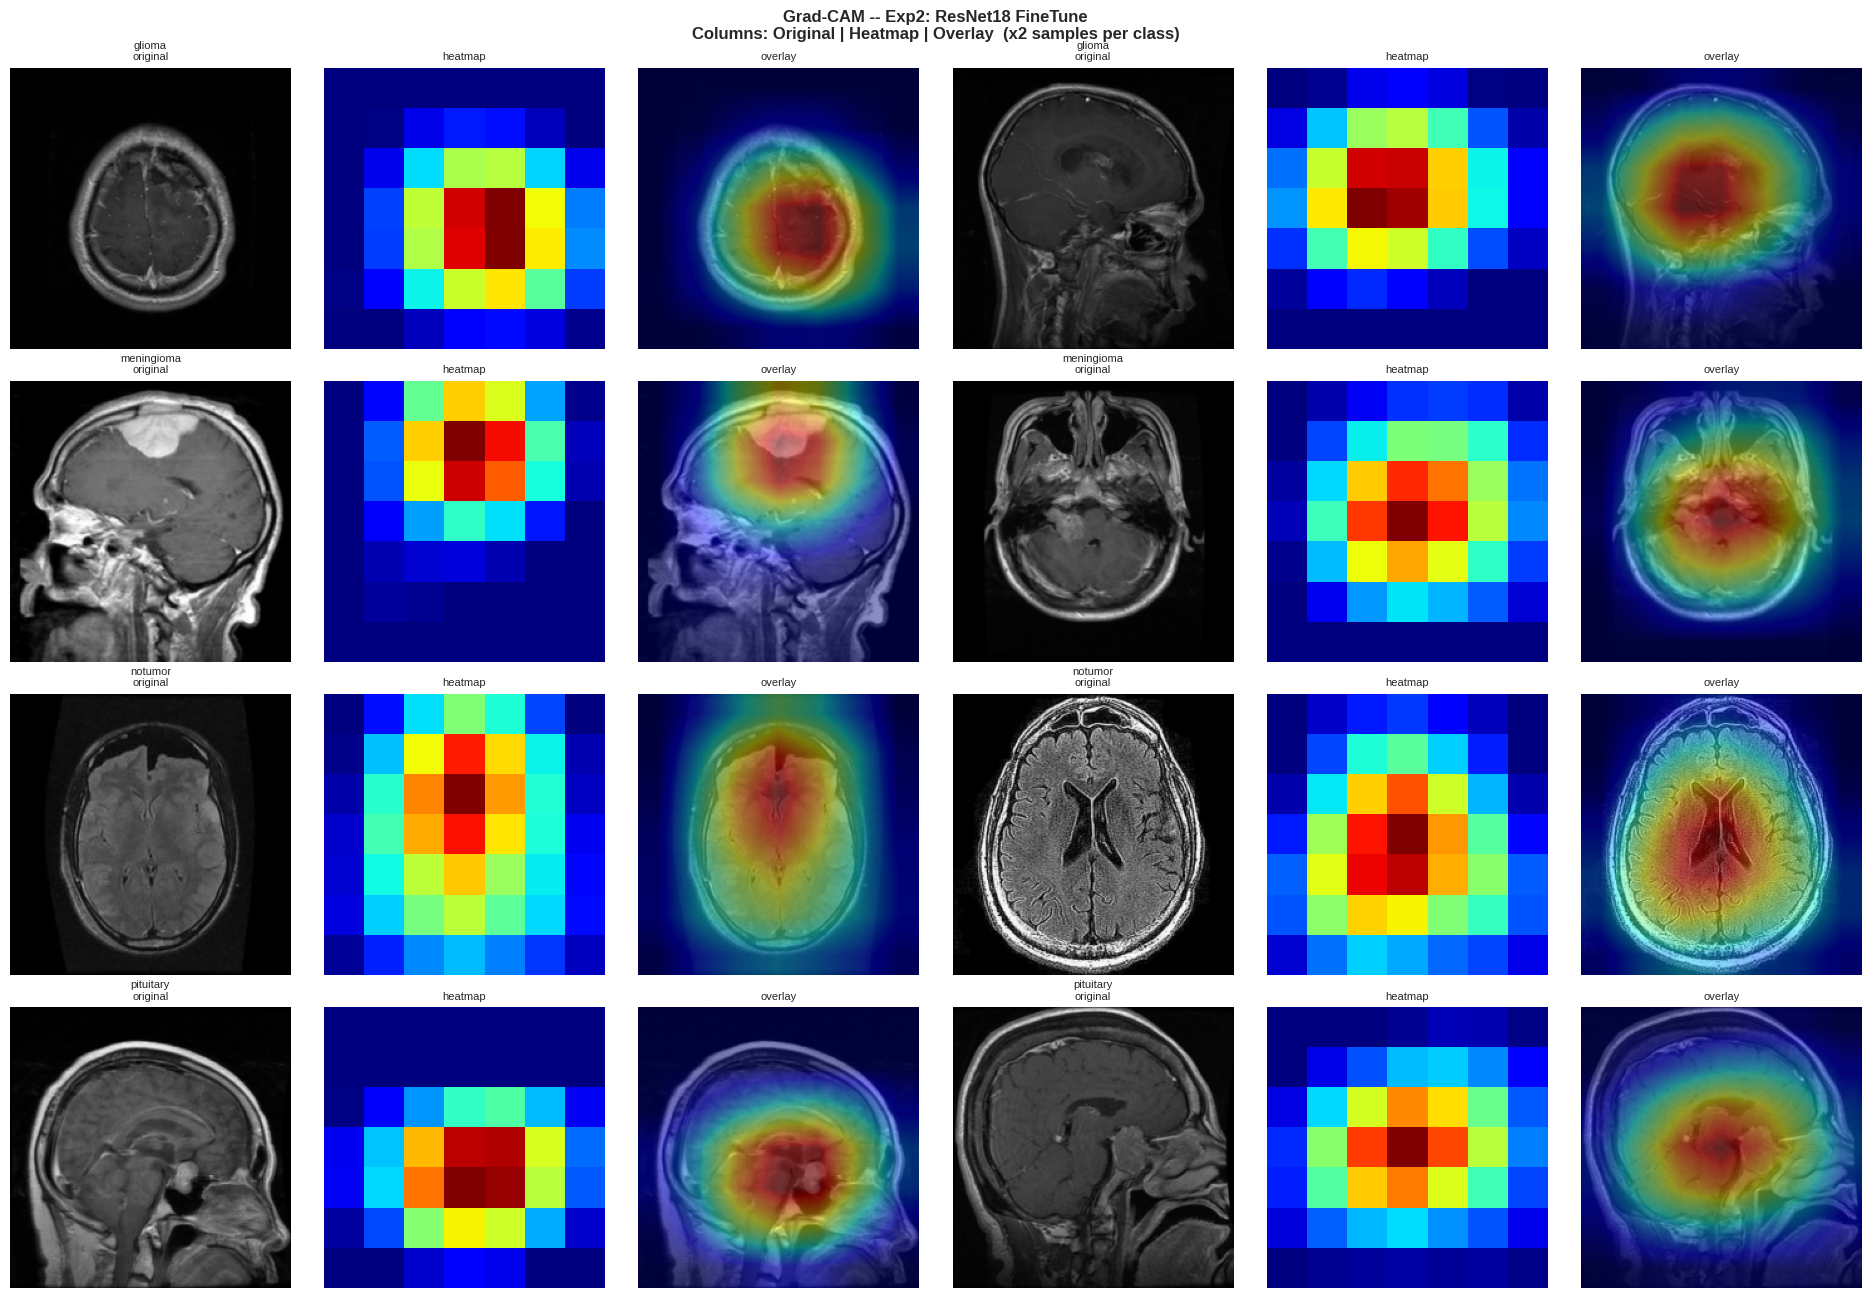

Grad-CAM heatmaps saved


In [35]:
# Visualise Grad-CAM heatmaps
# Layout: 4 rows (one per class) x 6 cols (2 samples x [original, heatmap, overlay])
gradcam = GradCAM(best_model, target_layer)

fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(19, NUM_CLASSES * 3.3))
fig.suptitle(
    f'Grad-CAM -- {exp_labels[best_key]}\n'
    'Columns: Original | Heatmap | Overlay  (x2 samples per class)',
    fontsize=12, fontweight='bold'
)

for cls_idx, cls_name in enumerate(CLASSES):
    for sample_idx in range(min(2, len(cam_samples[cls_idx]))):
        img_t     = cam_samples[cls_idx][sample_idx]
        # requires_grad_(True) needed so .backward() can flow gradients
        input_dev = img_t.unsqueeze(0).to(DEVICE).requires_grad_(True)
        heatmap   = gradcam(input_dev, class_idx=cls_idx)

        col = sample_idx * 3
        axes[cls_idx, col    ].imshow(denorm(img_t), cmap='gray')
        axes[cls_idx, col    ].set_title(f'{cls_name}\noriginal', fontsize=8)
        axes[cls_idx, col + 1].imshow(heatmap, cmap='jet')
        axes[cls_idx, col + 1].set_title('heatmap', fontsize=8)
        axes[cls_idx, col + 2].imshow(overlay_heatmap(img_t, heatmap))
        axes[cls_idx, col + 2].set_title('overlay', fontsize=8)
        for c in [col, col+1, col+2]:
            axes[cls_idx, c].axis('off')

gradcam.remove_hooks()  # critical: prevents memory leak from lingering hooks
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'week3_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grad-CAM heatmaps saved')

### Grad-CAM - How to Read the Maps

| Colour | Meaning |
|--------|---------|
| Red / warm | High model attention |
| Blue / cool | Low model attention |

**Expected patterns:**
- **Glioma:** attention on an abnormal intra-brain region
- **Meningioma:** attention near a peripheral/extra-axial region
- **Pituitary:** attention near the central skull base
- **No Tumor:** no sharp tumor-specific hotspot

If Grad-CAM focuses mainly on skull edges or background corners, the model may be using a shortcut instead of tumor anatomy.

---
## 14. Discussion

### Main result
The best Week 3 model is **ResNet18 full fine-tuning**. It reached **98.24% validation accuracy** and **99.07% test accuracy** with weighted precision, recall, and F1-score all at **99.07%**.

### Why full fine-tuning worked best
The frozen ResNet18 trained quickly but stopped at 81.48% validation accuracy because only the classifier head could adapt to MRI data. Full fine-tuning allowed the pretrained filters to adjust to tumor texture and MRI intensity patterns. Differential learning rates kept this adaptation controlled: the backbone used a smaller learning rate than the new classifier head.

### ResNet18 vs EfficientNet-B0
EfficientNet-B0 was strong at 97.78% validation accuracy, but ResNet18 fine-tuning was slightly better on this split. The difference is small, so the practical conclusion is that full fine-tuning matters more than the specific compact backbone used here.

### Overfitting
All final train-validation accuracy gaps were below 5%, so the models did not show severe overfitting. Data augmentation, ImageNet pretraining, dropout in the classifier head, and early stopping/checkpointing all helped generalisation.

### Remaining challenges
1. Glioma vs meningioma remains the most common confusion pattern.
2. Softmax probabilities can still be overconfident.
3. 224 x 224 resizing may remove fine boundary details.

### Plan for Week 4
- Apply Grad-CAM to every misclassified image.
- Add temperature scaling for probability calibration.
- Try a higher-capacity model only if it remains explainable.
- Consider skull-stripping preprocessing to reduce background shortcuts.
- Export the best model checkpoint for deployment or demo use.

---
## 15. Reproducibility: Reloading the Best Model

This section shows how to reload a saved checkpoint in a fresh session — important for Week 4 so we don't re-train from scratch.

In [36]:
# How to reload a checkpoint in a new session
# Steps:
#   1. Build the same model architecture
#   2. Load the state dict from the .pth file
#   3. Set eval mode before inference

name_map    = {'exp1': 'resnet18_frozen', 'exp2': 'resnet18_finetune', 'exp3': 'efficientnet_b0'}
builder_map = {'exp1': build_resnet18_frozen, 'exp2': build_resnet18_finetune, 'exp3': build_efficientnet_b0}

ckpt_path      = MODELS_DIR / f'{name_map[best_key]}.pth'
reloaded_model = builder_map[best_key](num_classes=NUM_CLASSES).to(DEVICE)
checkpoint     = torch.load(ckpt_path, map_location=DEVICE)
reloaded_model.load_state_dict(checkpoint['model_state_dict'])
reloaded_model.eval()

print(f'Reloaded: {ckpt_path}')
print(f'  Saved at epoch     : {checkpoint["epoch"]}')
print(f'  Saved val accuracy : {checkpoint["val_acc"]:.2f}%')

# Sanity check
quick = evaluate_model(reloaded_model, test_loader, DEVICE)
print(f'  Reloaded test acc  : {quick["accuracy"]*100:.2f}%  (should match Section 11)')

Reloaded: results/models/resnet18_finetune.pth
  Saved at epoch     : 24
  Saved val accuracy : 98.24%


  Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

  Reloaded test acc  : 99.07%  (should match Section 11)


---
## 16. Week 3 Summary

In [37]:
print(' WEEK 3 SUMMARY')

print('\n COMPLETED:')
for i, item in enumerate([
    '3 transfer learning experiments (ResNet18-Frozen, ResNet18-FineTune, EfficientNet-B0)',
    'Differential learning rates (backbone 10-20x slower than head)',
    'Early stopping + model checkpointing per experiment',
    'Overfitting gap analysis (train - val accuracy over epochs)',
    'Validation-based model selection (test set never used for tuning)',
    'Per-class accuracy breakdown + confusion matrix on test set',
    'Error analysis: 10 misclassified images + confusion pair counts',
    'Grad-CAM visualisation for interpretability (all 4 classes)',
    'Checkpoint reload demonstration for reproducibility',
], 1):
    print(f'  {i}. {item}')

print('\n EXPERIMENT LEADERBOARD:')
print(leaderboard.to_string(index=False))

print(f'\n BEST MODEL   : {exp_labels[best_key]}')
print(f'  Test Accuracy : {test_results["accuracy"]*100:.2f}%')
print(f'  Test F1-Score : {test_results["f1"]*100:.2f}%')
print(f'  vs Week 2 CNN : {(test_results["accuracy"]-0.9231)*100:+.2f} percentage points')

 WEEK 3 SUMMARY

 COMPLETED:
  1. 3 transfer learning experiments (ResNet18-Frozen, ResNet18-FineTune, EfficientNet-B0)
  2. Differential learning rates (backbone 10-20x slower than head)
  3. Early stopping + model checkpointing per experiment
  4. Overfitting gap analysis (train - val accuracy over epochs)
  5. Validation-based model selection (test set never used for tuning)
  6. Per-class accuracy breakdown + confusion matrix on test set
  7. Error analysis: 10 misclassified images + confusion pair counts
  8. Grad-CAM visualisation for interpretability (all 4 classes)
  9. Checkpoint reload demonstration for reproducibility

 EXPERIMENT LEADERBOARD:
                       Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%) Eval Set
Week 2 Custom CNN (baseline)         92.31          92.30       92.31         92.30     Test
       Exp1: ResNet18 Frozen         81.48          81.39       81.48         81.01      Val
     Exp2: ResNet18 FineTune         98.24          98.25 